In [ ]:
# 1. Cài đặt pyspark
!pip install pyspark

Function tương quan giữa Pandas và Pyspark

In [1]:
# 2. Khởi tạo SparkSession
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Khởi tạo Spark Session
spark = SparkSession.builder.appName("PySparkBasics").getOrCreate()

In [2]:
from pyspark.sql.types import TimestampType, DoubleType
import random
from datetime import datetime, timedelta
import uuid

In [ ]:
# 1. Tạo dữ liệu giả lập (Thay cho bước đọc file)
data = [("Dien thoai", "Dien tu", 1000, 2),
        ("Tu lanh", "Gia dung", 1500, 1),
        ("Laptop", "Dien tu", 2000, 5),
        ("May giat", "Gia dung", 1200, 2),
        ("Chuot", "Dien tu", 50, 10)]

columns = ["TenSanpham", "DanhMuc", "Gia", "SoLuong"]

# Tạo DataFrame
df = spark.createDataFrame(data, columns)

# 2. Hiển thị dữ liệu (Giống df.head() trong Pandas)
print("Hiển thị 5 dòng đầu tiên:")
df.show(5)

Hiển thị 5 dòng đầu tiên:
+----------+--------+----+-------+
|TenSanpham| DanhMuc| Gia|SoLuong|
+----------+--------+----+-------+
|Dien thoai| Dien tu|1000|      2|
|   Tu lanh|Gia dung|1500|      1|
|    Laptop| Dien tu|2000|      5|
|  May giat|Gia dung|1200|      2|
|     Chuot| Dien tu|  50|     10|
+----------+--------+----+-------+



In [ ]:
# 3. Xem cấu trúc dữ liệu (Giống df.info())
print("Cấu trúc schema:")
df.printSchema()

Cấu trúc schema:
root
 |-- TenSanpham: string (nullable = true)
 |-- DanhMuc: string (nullable = true)
 |-- Gia: long (nullable = true)
 |-- SoLuong: long (nullable = true)



In [ ]:
# 4. Thống kê mô tả (Giống df.describe())
print("Thống kê mô tả:")
df.describe(["Gia", "SoLuong"]).show()

Thống kê mô tả:
+-------+-----------------+------------------+
|summary|              Gia|           SoLuong|
+-------+-----------------+------------------+
|  count|                5|                 5|
|   mean|           1150.0|               4.0|
| stddev|721.1102550927978|3.6742346141747673|
|    min|               50|                 1|
|    max|             2000|                10|
+-------+-----------------+------------------+



In [ ]:
# 5. Thao tác chọn cột và tạo cột mới (Giống df['new_col'] = ...)
# Tính tổng tiền = Gia * SoLuong
df_with_total = df.withColumn("TongTien", F.col("Gia") * F.col("SoLuong"))
df_with_total.show()

+----------+--------+----+-------+--------+
|TenSanpham| DanhMuc| Gia|SoLuong|TongTien|
+----------+--------+----+-------+--------+
|Dien thoai| Dien tu|1000|      2|    2000|
|   Tu lanh|Gia dung|1500|      1|    1500|
|    Laptop| Dien tu|2000|      5|   10000|
|  May giat|Gia dung|1200|      2|    2400|
|     Chuot| Dien tu|  50|     10|     500|
+----------+--------+----+-------+--------+



In [ ]:
# 6. Lọc dữ liệu (Giống df[df['Gia'] > 1000])
print("Các sản phẩm có giá trên 1000:")
df_with_total.filter(F.col("Gia") > 1000).show()

Các sản phẩm có giá trên 1000:
+----------+--------+----+-------+--------+
|TenSanpham| DanhMuc| Gia|SoLuong|TongTien|
+----------+--------+----+-------+--------+
|   Tu lanh|Gia dung|1500|      1|    1500|
|    Laptop| Dien tu|2000|      5|   10000|
|  May giat|Gia dung|1200|      2|    2400|
+----------+--------+----+-------+--------+



In [ ]:
# 7. Gom nhóm và Tính toán (Aggregation - Giống df.groupby().agg())
print("Tổng doanh thu theo từng Danh mục:")
summary_df = df_with_total.groupBy("DanhMuc").agg(
    F.sum("TongTien").alias("TongDoanhThu"),
    F.avg("Gia").alias("GiaTrungBinh"),
    F.count("TenSanpham").alias("SoLuongMatHang")
)
summary_df.show()

Tổng doanh thu theo từng Danh mục:
+--------+------------+------------------+--------------+
| DanhMuc|TongDoanhThu|      GiaTrungBinh|SoLuongMatHang|
+--------+------------+------------------+--------------+
|Gia dung|        3900|            1350.0|             2|
| Dien tu|       12500|1016.6666666666666|             3|
+--------+------------+------------------+--------------+



In [ ]:
# 8. Sắp xếp (Giống df.sort_values())
print("Sắp xếp theo doanh thu giảm dần:")
summary_df.orderBy(F.col("TongDoanhThu").desc()).show()

Sắp xếp theo doanh thu giảm dần:
+--------+------------+------------------+--------------+
| DanhMuc|TongDoanhThu|      GiaTrungBinh|SoLuongMatHang|
+--------+------------+------------------+--------------+
| Dien tu|       12500|1016.6666666666666|             3|
|Gia dung|        3900|            1350.0|             2|
+--------+------------+------------------+--------------+



In [ ]:
# 9. Lưu kết quả ra file mới (Giống df.to_csv())
# Lưu ý: Spark sẽ tạo ra một thư mục chứa các file con vì nó xử lý phân tán
summary_df.write.mode("overwrite").csv("ket_qua_doanh_thu.csv", header=True)
print("Đã lưu file thành công!")

In [ ]:
# Hiển thị giống pandas
df.limit(10).toPandas()

,TenSanpham,DanhMuc,Gia,SoLuong
0,Dien thoai,Dien tu,1000,2
1,Tu lanh,Gia dung,1500,1
2,Laptop,Dien tu,2000,5
3,May giat,Gia dung,1200,2
4,Chuot,Dien tu,50,10


Các hàm cleaning data phổ biến Pyspark

In [4]:
#Function to generate random dates

def generate_random_dates(start_date, end_date, n):
  start_timestamp = datetime.strptime(start_date, '%Y-%m-%d %H:%M:%S')
  end_timestamp = datetime.strptime(end_date, '%Y-%m-%d %H:%M:%S')
  delta = end_timestamp - start_timestamp

  dates = []
  for _ in range(n):
    random_days = random.randint(0, delta.days)
    random_seconds = random.randint(0,86400)
    random_date = start_timestamp + timedelta(days=random_days, seconds=random_seconds)
    dates.append(random_date.strftime('%Y-%m-%d %H:%M:%S'))
  return dates

# Define values for products, category, brand
products = ['A','B','C','D','E','F','G','H','I','J','K']
categories = ['electronic.smartphone','applicances.machine','appliances.washer','computers.notebook','furniture.living_room/sofa']
brands = ['A1','B1','C1','D1','E1','F1','G1','H1','I1','J1','K1']
event = ['view','click','purchase']

#Generate sample data
n = 1000
start_date = '2026-03-23 00:00:00'
end_date = '2026-04-30 23:59:30'

# Generate random data
dates = generate_random_dates(start_date, end_date, n)
event = [random.choice(event) for _ in range(n)]
product_id = [random.choice(products) for _ in range(n)]
category = [random.choice(categories) for _ in range(n)]
brand = [random.choice(brands) for _ in range(n)]

price = [round(random.uniform(100, 1000), 2) for _ in range(n)]
user_id = [random.randint(1,100000) for _ in range(n)]
user_session = [str(uuid.uuid4()) for _ in range(n)]

#Create dataframe
data = list(zip(dates, event, product_id, category, brand, price, user_id, user_session))
columns = ['time','event','product_id','category','brand','price','user_id','user_session']

df = spark.createDataFrame(data, columns)
df.show(5)

+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
|               time|   event|product_id|            category|brand| price|user_id|        user_session|
+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
|2026-03-29 14:55:32|purchase|         E|electronic.smartp...|   G1|248.42|  56205|12959769-6431-4e8...|
|2026-04-29 19:36:21|    view|         I|furniture.living_...|   F1|687.33|  21296|cc064717-0ac0-47e...|
|2026-04-04 22:38:44|purchase|         K|  computers.notebook|   K1|820.16|  28960|87381b28-0153-4b3...|
|2026-04-12 10:36:50|   click|         G|furniture.living_...|   J1|527.32|  12147|3e1faa15-c2c4-4e9...|
|2026-03-27 08:55:40|purchase|         A| applicances.machine|   J1|405.05|   6385|39bed9d1-c0e4-410...|
+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
only showing top 5 rows


In [5]:
# trimming and lower case for column
df_trim = df.withColumn('event', F.lower(F.trim(F.col('event'))))\
            .withColumn('brand', F.lower(F.trim(F.col('brand'))))
df_trim.show(5)

+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
|               time|   event|product_id|            category|brand| price|user_id|        user_session|
+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
|2026-03-29 14:55:32|purchase|         E|electronic.smartp...|   g1|248.42|  56205|12959769-6431-4e8...|
|2026-04-29 19:36:21|    view|         I|furniture.living_...|   f1|687.33|  21296|cc064717-0ac0-47e...|
|2026-04-04 22:38:44|purchase|         K|  computers.notebook|   k1|820.16|  28960|87381b28-0153-4b3...|
|2026-04-12 10:36:50|   click|         G|furniture.living_...|   j1|527.32|  12147|3e1faa15-c2c4-4e9...|
|2026-03-27 08:55:40|purchase|         A| applicances.machine|   j1|405.05|   6385|39bed9d1-c0e4-410...|
+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+
only showing top 5 rows


In [6]:
# Replace empty, unknown with null
for col_name in ['event','category']:
  df_trim = df_trim.withColumn(
      col_name,
      F.when(F.col(col_name).isin("N/A","unknown",""), None).otherwise(F.col(col_name))
  )

# Fill missing values with default:
df_filled = df_trim.fillna({
    'product_id':'unspecified',
    'brand':'new_brand',
    'price':0.0
})

df_filled.select('event','category','product_id','brand').show(5)

+--------+--------------------+----------+-----+
|   event|            category|product_id|brand|
+--------+--------------------+----------+-----+
|purchase|electronic.smartp...|         E|   g1|
|    view|furniture.living_...|         I|   f1|
|purchase|  computers.notebook|         K|   k1|
|   click|furniture.living_...|         G|   j1|
|purchase| applicances.machine|         A|   j1|
+--------+--------------------+----------+-----+
only showing top 5 rows


In [8]:
# Convert 'time' to Timestamp and ensure price is float
df_types = df_filled.withColumn('time', F.col('time').cast(TimestampType()))\
                    .withColumn('price', F.col('price').cast(DoubleType()))

df_types.printSchema()

root
 |-- time: timestamp (nullable = true)
 |-- event: string (nullable = true)
 |-- product_id: string (nullable = false)
 |-- category: string (nullable = true)
 |-- brand: string (nullable = false)
 |-- price: double (nullable = false)
 |-- user_id: long (nullable = true)
 |-- user_session: string (nullable = true)



In [9]:
# Select key columns
df_columns = df_types.select('time','category','brand','price')
df_columns.show(5)

+-------------------+--------------------+-----+------+
|               time|            category|brand| price|
+-------------------+--------------------+-----+------+
|2026-03-29 14:55:32|electronic.smartp...|   g1|248.42|
|2026-04-29 19:36:21|furniture.living_...|   f1|687.33|
|2026-04-04 22:38:44|  computers.notebook|   k1|820.16|
|2026-04-12 10:36:50|furniture.living_...|   j1|527.32|
|2026-03-27 08:55:40| applicances.machine|   j1|405.05|
+-------------------+--------------------+-----+------+
only showing top 5 rows


In [10]:
# Convert to Pandas for easy apply visualization libraries
df_pandas = df_columns.toPandas()

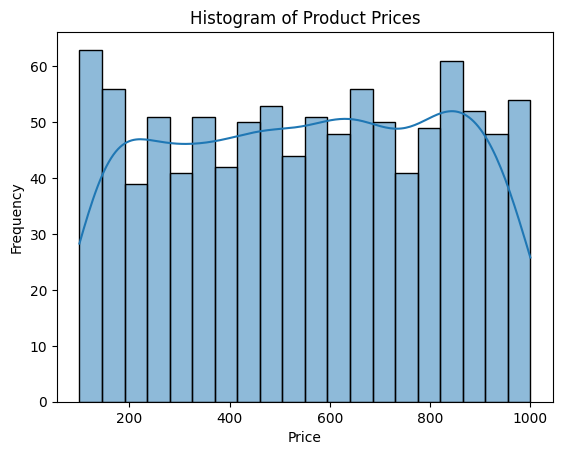

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df_pandas['price'], kde=True, bins = 20)
plt.title('Histogram of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Some operations

In [13]:
#filter
df_filter = df.filter(df.event == 'click')
df_filter.show(5)

+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+
|               time|event|product_id|            category|brand| price|user_id|        user_session|
+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+
|2026-04-12 10:36:50|click|         G|furniture.living_...|   J1|527.32|  12147|3e1faa15-c2c4-4e9...|
|2026-04-16 08:16:53|click|         C| applicances.machine|   C1|484.65|  12646|d12389e3-99c4-41f...|
|2026-04-05 17:48:27|click|         E|   appliances.washer|   J1|865.63|  43217|3592f0ee-ac2b-4da...|
|2026-04-02 04:12:53|click|         F|furniture.living_...|   G1|117.99|   7178|d8210e48-0b02-48f...|
|2026-04-21 22:15:13|click|         B| applicances.machine|   A1|371.27|  39076|9b5e759a-b188-4e2...|
+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+
only showing top 5 rows


In [14]:
# Create a new column
df_new_col = df_filter.withColumn('total_spend', F.col('price')*2)
df_new_col.show(5)

+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+-----------+
|               time|event|product_id|            category|brand| price|user_id|        user_session|total_spend|
+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+-----------+
|2026-04-12 10:36:50|click|         G|furniture.living_...|   J1|527.32|  12147|3e1faa15-c2c4-4e9...|    1054.64|
|2026-04-16 08:16:53|click|         C| applicances.machine|   C1|484.65|  12646|d12389e3-99c4-41f...|      969.3|
|2026-04-05 17:48:27|click|         E|   appliances.washer|   J1|865.63|  43217|3592f0ee-ac2b-4da...|    1731.26|
|2026-04-02 04:12:53|click|         F|furniture.living_...|   G1|117.99|   7178|d8210e48-0b02-48f...|     235.98|
|2026-04-21 22:15:13|click|         B| applicances.machine|   A1|371.27|  39076|9b5e759a-b188-4e2...|     742.54|
+-------------------+-----+----------+--------------------+-----+------+-------+--------

In [15]:
# Drop duplicate
df_drop_dup = df_new_col.dropDuplicates()
df_drop_dup.show(5)

+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+-----------+
|               time|event|product_id|            category|brand| price|user_id|        user_session|total_spend|
+-------------------+-----+----------+--------------------+-----+------+-------+--------------------+-----------+
|2026-04-10 03:51:30|click|         K| applicances.machine|   I1|326.14|  38637|3e93309b-917e-4ac...|     652.28|
|2026-03-31 05:14:07|click|         B|electronic.smartp...|   C1|365.09|  24879|fb79ff17-00b9-484...|     730.18|
|2026-04-18 19:44:31|click|         J|  computers.notebook|   E1|829.91|  62448|a30466cd-c361-459...|    1659.82|
|2026-04-26 07:34:56|click|         H| applicances.machine|   I1|526.94|  65534|5c0aace6-22d9-494...|    1053.88|
|2026-03-26 10:00:18|click|         C|   appliances.washer|   D1|726.29|   4713|3d499ce8-9a8b-431...|    1452.58|
+-------------------+-----+----------+--------------------+-----+------+-------+--------

In [16]:
# Groupby
df_group =  df_drop_dup.groupBy('category').agg(
    F.avg('price').alias('ave_price'),
    F.sum('total_spend').alias('total_spend')
)
df_group.show(5)

+--------------------+------------------+------------------+
|            category|         ave_price|       total_spend|
+--------------------+------------------+------------------+
| applicances.machine|467.59154929577466|           66398.0|
|electronic.smartp...|  536.757049180328|65484.360000000015|
|   appliances.washer| 508.3166666666668|64047.900000000016|
|furniture.living_...| 648.6989230769229| 84330.85999999999|
|  computers.notebook| 578.0232432432433| 85547.44000000002|
+--------------------+------------------+------------------+



In [18]:
# Timestamp operation
df = df.withColumn("day_of_week", F.date_format(F.col("time"),"EEEE")) \
      .withColumn("hour_of_day", F.hour(F.col("time"))) \
      .withColumn("date", F.to_date(F.col("time"))) \
      .withColumn("is_weekend", F.expr("dayofweek(time) IN (1,7)"))

df.show(5)

+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+-----------+-----------+----------+----------+
|               time|   event|product_id|            category|brand| price|user_id|        user_session|day_of_week|hour_of_day|      date|is_weekend|
+-------------------+--------+----------+--------------------+-----+------+-------+--------------------+-----------+-----------+----------+----------+
|2026-03-29 14:55:32|purchase|         E|electronic.smartp...|   G1|248.42|  56205|12959769-6431-4e8...|     Sunday|         14|2026-03-29|      true|
|2026-04-29 19:36:21|    view|         I|furniture.living_...|   F1|687.33|  21296|cc064717-0ac0-47e...|  Wednesday|         19|2026-04-29|     false|
|2026-04-04 22:38:44|purchase|         K|  computers.notebook|   K1|820.16|  28960|87381b28-0153-4b3...|   Saturday|         22|2026-04-04|      true|
|2026-04-12 10:36:50|   click|         G|furniture.living_...|   J1|527.32|  12147|3e1faa15-c2

In [19]:
# Save file
df.write.mode("overwrite").json("sample.csv")


# Finally: Caching and Broadcast

In [23]:
# Generate sample data with 1 million row
sales_data = [(i, f"user_{i%100}", i%50) for i in range(1000000)]
sales_df = spark.createDataFrame(sales_data, ["sale_id", "user_id", "state_code"])

#i: Là ID của mỗi giao dịch (từ 0 đến 999,999)
#f"user_{i%100}": Tạo ra ID người dùng. Phép chia lấy dư %100 giúp giới hạn chỉ có 100 người dùng khác nhau (từ user_0 đến user_99).
#i%50: Tạo ra mã bang (state_code). Phép chia lấy dư %50 giúp giới hạn có 50 mã bang khác nhau (từ 0 đến 49).

# Create a small lookup df for join
states = [
    (0,'Ha noi'),
    (1,'Ho chi minh'),
    (2,'Da nang'),
    (3,'Hai phong'),
    (4,'Nha Trang')
] + [(i, f"State_{i}") for i in range(5,50)]
#Dùng List Comprehension để tự động tạo ra các tên bang giả lập cho các mã còn lại từ 5 đến 49 (ví dụ: State_5, State_6,...).

state_df = spark.createDataFrame(states, ["state_code", "state_name"])

In [25]:
# Caching
filted_sale = sales_df.filter(sales_df.state_code > 4).cache()

# At first action, all will be executed
filted_sale.groupby('user_id').count().show(5)

+-------+-----+
|user_id|count|
+-------+-----+
|user_58|10000|
|user_73|10000|
|user_94|10000|
|user_85|10000|
|user_14|10000|
+-------+-----+
only showing top 5 rows


In [26]:
# At followed actions, data will be taken directly from RAM
filted_sale.select('state_code').distinct().count()

45

In [27]:
# Broadcast
join_broadcast = sales_df.join(
    F.broadcast(state_df),
    on = 'state_code')
join_broadcast.show(5)

+----------+-------+-------+-----------+
|state_code|sale_id|user_id| state_name|
+----------+-------+-------+-----------+
|         0|      0| user_0|     Ha noi|
|         1|      1| user_1|Ho chi minh|
|         2|      2| user_2|    Da nang|
|         3|      3| user_3|  Hai phong|
|         4|      4| user_4|  Nha Trang|
+----------+-------+-------+-----------+
only showing top 5 rows
